In [1]:
import os
import sys
import json
from pathlib import Path
sys.path.append(os.path.abspath('..'))

# ----------- local imports ----------- 
from utils import show_images, make_grid
from constants import TRAIN_PATH, BASE_DIR

In [78]:
import torch
import numpy as np
from PIL import Image
import skimage as ski
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F
from controlnet_aux import OpenposeDetector
from controlnet_aux.util import HWC3, resize_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = torch.Generator(device=device).manual_seed(42)
# dtype = torch.bfloat16
dtype = torch.float32

# openpose = OpenposeDetector.from_pretrained("lllyasviel/ControlNet").to(device)


# 1. Load images, Keypoints

In [52]:
src_img_path = BASE_DIR / 'datasets/celebrities/mo_salah/faces/face4.png'
tar_img_path = BASE_DIR / 'datasets/celebrities/mo_salah/faces/face8.jpg'

resolution = 512
src_image = Image.open(src_img_path).convert("RGB").resize((resolution, resolution))
tar_image = Image.open(tar_img_path).convert("RGB").resize((resolution, resolution))

In [ ]:
import cv2
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

def extract_mp_mesh(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (resolution, resolution))
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = face_mesh.process(rgb).multi_face_landmarks[0].landmark
    return np.array([(lm.x * image.shape[1] , lm.y  * image.shape[0]) for lm in results])

def draw_landmarks(image_path, landmarks):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (resolution, resolution))
    for lm in landmarks:
        cv2.circle(image, (int(lm[0]), int(lm[1])), 1, (0, 255, 0), -1)
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return rgb

I0000 00:00:1750347731.868513   18389 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1750347731.885285   23187 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.1.1), renderer: llvmpipe (LLVM 19.1.7, 256 bits)


W0000 00:00:1750347731.891541   23173 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750347731.901861   23178 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [73]:
src_llm = extract_mp_mesh(src_img_path)
tar_llm = extract_mp_mesh(tar_img_path)

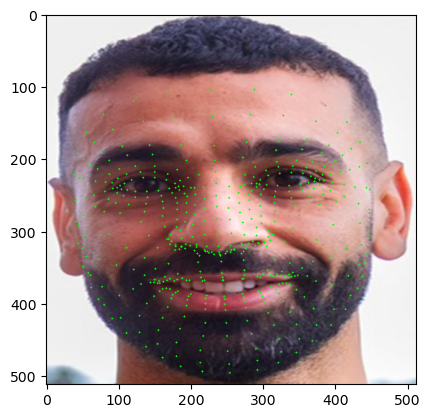

In [74]:
plt.imshow(draw_landmarks(src_img_path, src_llm))

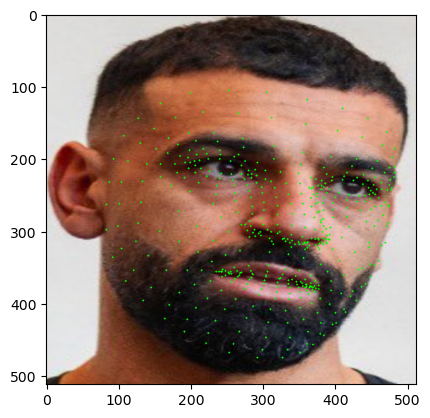

In [75]:
plt.imshow(draw_landmarks(tar_img_path, tar_llm))

In [76]:
def get_openpose_keypoints(detector, input_image, detect_resolution, include_hand=True, include_face=True):
    if not isinstance(input_image, np.ndarray):
        input_image = np.array(input_image, dtype=np.uint8)
    input_image = HWC3(input_image)
    input_image = resize_image(input_image, detect_resolution)
    return detector.detect_poses(input_image, include_hand, include_face)

In [ ]:
# src_result = get_openpose_keypoints(openpose, src_image, resolution, include_hand=True, include_face=True)
# tar_result = get_openpose_keypoints(openpose, tar_image, resolution, include_hand=True, include_face=True)

# src_kp = np.array([(kp.x, kp.y) for kp in src_result[0].face])
# tar_kp = np.array([(kp.x, kp.y) for kp in tar_result[0].face])

In [48]:
tps = ski.transform.ThinPlateSplineTransform()
tps.estimate(src_llm, tar_llm)

warped = ski.transform.warp(np.array(src_image), tps)

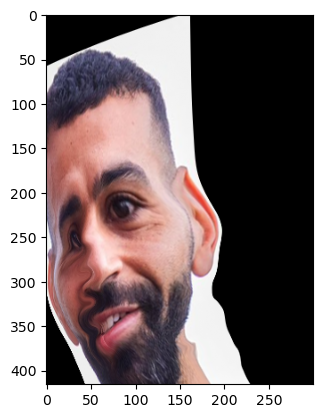

In [65]:
plt.imshow(warped)

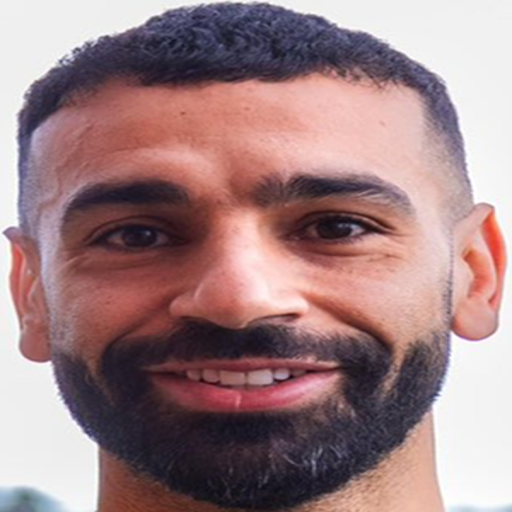

In [54]:
src_image

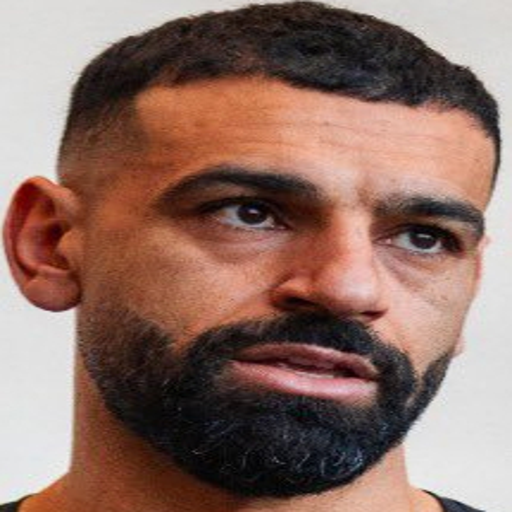

In [55]:
tar_image